<a href="https://colab.research.google.com/github/Adityatyagi077/student-performance-analysis/blob/main/student_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/student-marks-dataset")

print("Path to dataset files:", path)

100%|██████████| 949/949 [00:00<00:00, 1.14MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/student-marks-dataset/versions/1


In [73]:
from google.colab import files
files.upload()

Saving Student_Marks.csv to Student_Marks (1).csv


{'Student_Marks (1).csv': b'number_courses,time_study,Marks\r\n3,4.508,19.202\r\n4,0.096,7.734\r\n4,3.133,13.811\r\n6,7.909,53.018\r\n8,7.811,55.299\r\n6,3.211,17.822\r\n3,6.063,29.889\r\n5,3.413,17.264\r\n4,4.410,20.348\r\n3,6.173,30.862\r\n3,7.353,42.036\r\n7,0.423,12.132\r\n7,4.218,24.318\r\n3,4.274,17.672\r\n3,2.908,11.397\r\n4,4.260,19.466\r\n5,5.719,30.548\r\n8,6.080,38.490\r\n6,7.711,50.986\r\n8,3.977,25.133\r\n4,4.733,22.073\r\n6,6.126,35.939\r\n5,2.051,12.209\r\n7,4.875,28.043\r\n4,3.635,16.517\r\n3,1.407,6.623\r\n7,0.508,12.647\r\n8,4.378,26.532\r\n5,0.156,9.333\r\n4,1.299,8.837\r\n8,3.864,24.172\r\n3,1.923,8.100\r\n8,0.932,15.038\r\n6,6.594,39.965\r\n3,4.083,17.171\r\n3,7.543,43.978\r\n4,2.966,13.119\r\n6,7.283,46.453\r\n7,6.533,41.358\r\n6,7.775,51.142\r\n4,0.140,7.336\r\n6,2.754,15.725\r\n6,3.591,19.771\r\n5,1.557,10.429\r\n4,1.954,9.742\r\n3,2.061,8.924\r\n4,3.797,16.703\r\n4,4.779,22.701\r\n3,5.635,26.882\r\n5,3.913,19.106\r\n6,6.703,40.602\r\n6,4.130,22.184\r\n4,0.771,7

In [74]:
import pandas as pd
import numpy as np

In [75]:
df=pd.read_csv("Student_Marks.csv")
df

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


In [76]:
df.head(1)


,number_courses,time_study,Marks
0,3,4.508,19.202


In [77]:
print("Average marks",df["Marks"].mean())

Average marks 24.417689999999997


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [79]:
top=df.loc[df["Marks"].idxmax()]
print(f"Top record:\nMarks={top["Marks"]},study Time-{top["time_study"]}")


Top record:
Marks=55.299,study Time-7.811


In [80]:
failed=df[df["Marks"]<40]
print("Failed student: ",failed)

Failed student:      number_courses  time_study   Marks
0                3       4.508  19.202
1                4       0.096   7.734
2                4       3.133  13.811
5                6       3.211  17.822
6                3       6.063  29.889
..             ...         ...     ...
94               8       3.919  24.451
95               6       3.561  19.128
96               3       0.301   5.609
98               7       0.309  12.027
99               3       6.335  32.357

[81 rows x 3 columns]


In [86]:
def grade(Marks):
  if Marks>=40:
    return "A"
  elif Marks>=20:
    return "B"
  elif Marks>=10:
    return "C"

  else :
    return "Fail"
df["Grade"]=df["Marks"].apply(grade)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
 3   Grade           100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


In [88]:
df.columns=['NumberOfCourses','StudyTime','Score','Grade']

In [89]:
print(df["Grade"].value_counts())

Grade
C       34
B       31
A       19
Fail    16
Name: count, dtype: int64


In [90]:
print("Top 5 highestscoring records:")
df_sorted=df.sort_values(by="Score",ascending=False)
print(df_sorted.head())

Top 5 highestscoring records:
    NumberOfCourses  StudyTime   Score Grade
4                 8      7.811  55.299     A
80                7      7.957  54.321     A
56                8      7.641  53.359     A
54                8      7.591  53.158     A
3                 6      7.909  53.018     A


In [91]:
print("\n Top 5 Students: ")
print(df_sorted[["StudyTime","Grade","Score"]].head())


 Top 5 Students: 
    StudyTime Grade   Score
4       7.811     A  55.299
80      7.957     A  54.321
56      7.641     A  53.359
54      7.591     A  53.158
3       7.909     A  53.018


In [92]:
corr=df[["StudyTime","Score"]].corr()
# to find relation b/w columns
print("\nCorrelation:\n",corr)

if (corr.loc["StudyTime","Score"]>0):
  print("Insight: More study time tends to increase marks")
else:
  print("Insight: study time has weak or negative impact")


Correlation:
            StudyTime     Score
StudyTime   1.000000  0.942254
Score       0.942254  1.000000
Insight: More study time tends to increase marks


In [93]:
df.isnull().sum()

,0
NumberOfCourses,0
StudyTime,0
Score,0
Grade,0


In [94]:
# df.drop_duplicates()
# won't change original
df = df.drop_duplicates()

In [95]:
df.dtypes

,0
NumberOfCourses,int64
StudyTime,float64
Score,float64
Grade,object


In [96]:
df.columns=df.columns.str.strip().str.lower()

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NumberOfCourses  100 non-null    int64  
 1   StudyTime        100 non-null    float64
 2   Score            100 non-null    float64
 3   Grade            100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


In [102]:
corr=df[['NumberOfCourses','StudyTime','Score']].corr()
print(corr)
# studytime increses marks increases strong positive correletion

                 NumberOfCourses  StudyTime     Score
NumberOfCourses         1.000000   0.204844  0.417335
StudyTime               0.204844   1.000000  0.942254
Score                   0.417335   0.942254  1.000000


In [103]:
df.columns=['NumberOfCourses','StudyTime','Score','Grade']

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NumberOfCourses  100 non-null    int64  
 1   StudyTime        100 non-null    float64
 2   Score            100 non-null    float64
 3   Grade            100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


In [105]:
df.describe()

,NumberOfCourses,StudyTime,Score
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


In [106]:
# does study time affect performance let's check
df.groupby('Grade')['StudyTime'].mean()
df.groupby('NumberOfCourses')['StudyTime'].mean()


,StudyTime
NumberOfCourses,
3,3.685773
4,3.598524
5,3.070600
6,4.838750
7,4.242667
8,4.955750


In [107]:
df['Grade'].value_counts()

,count
Grade,
C,34
B,31
A,19
Fail,16


Text(0, 0.5, 'Frequency')

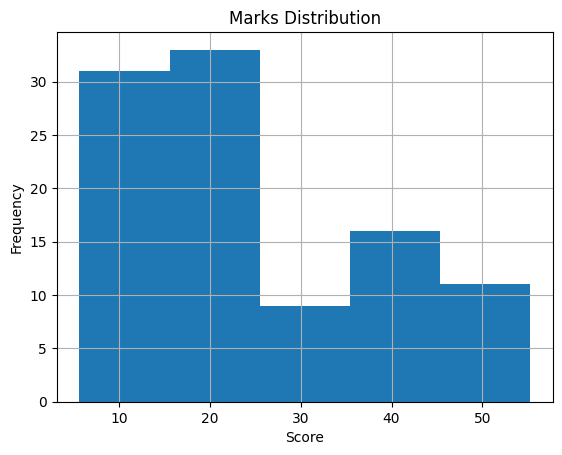

In [108]:
import matplotlib.pyplot as plt
df['Score'].hist(bins=5)
plt.title("Marks Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

Text(0, 0.5, 'Marks')

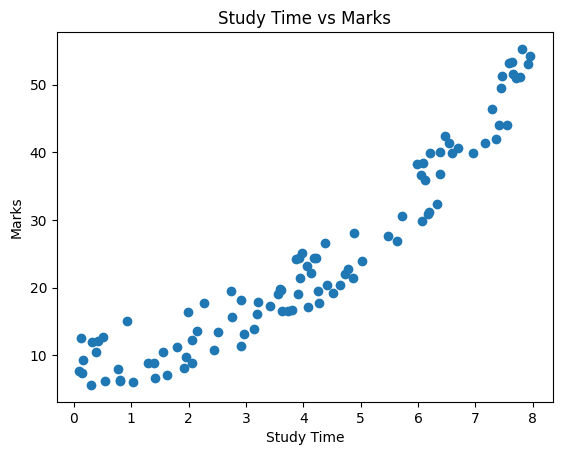

In [109]:
plt.scatter(df['StudyTime'], df['Score'])
plt.title("Study Time vs Marks")
plt.xlabel("Study Time")
plt.ylabel("Marks")

Text(0, 0.5, 'Study Time')

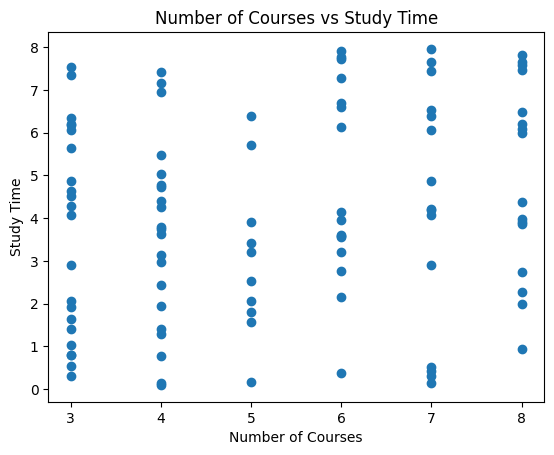

In [110]:
plt.scatter(df['NumberOfCourses'],df['StudyTime'])
plt.title("Number of Courses vs Study Time")
plt.xlabel("Number of Courses")
plt.ylabel("Study Time")


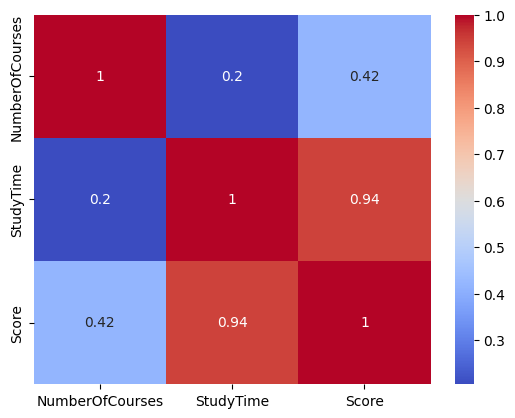

In [111]:
import seaborn as sns
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True,cmap='coolwarm')
plt.show()

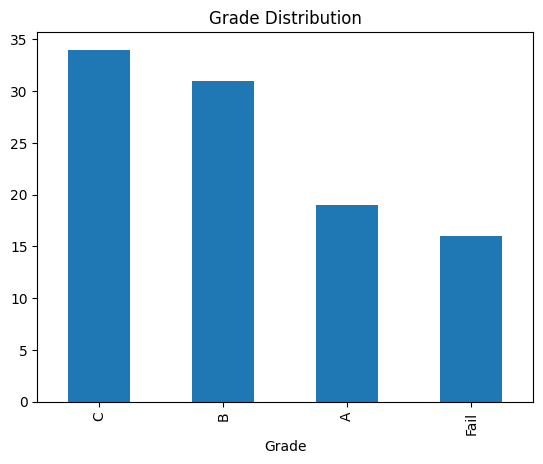

In [112]:
df['Grade'].value_counts().plot(kind='bar')
plt.title("Grade Distribution")
plt.show()

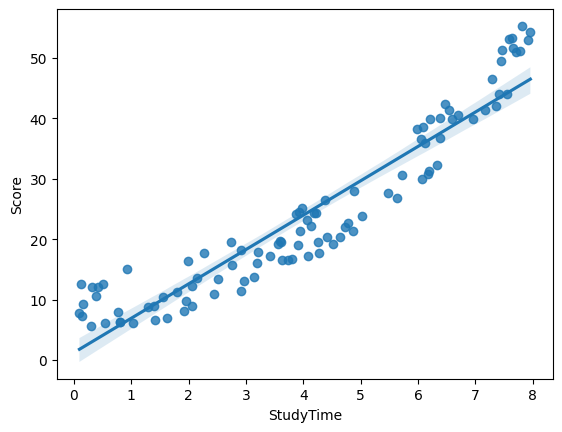

In [113]:
sns.regplot(x='StudyTime',y='Score',data=df)
plt.show()

In [114]:
#  marks = m1*(time_study) + m2*(number_courses) + b
#  linear reggresion in my data set
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [115]:
x=df[['StudyTime','NumberOfCourses']]
y=df['Score']

In [116]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4  )

In [117]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [118]:
# # Why Linear Regression?

# Because the target variable (marks) is continuous and shows a strong linear relationship with study time.

# ❓ Why train-test split?

# To evaluate model performance on unseen data and avoid overfitting.

# ❓ Why 0.2 test size?

# It provides a good balance between training and evaluation, ensuring sufficient data for both.

In [119]:
y_pred=model.predict(X_test)
print(y_pred)


[2.55667258e+01 3.77603972e+01 7.38246517e-03 3.26778433e+01
 2.44622564e+01 1.96885621e+01 3.81096004e+01 3.85757765e+01
 1.86372079e+01 2.58129877e+01 1.03964980e+01 1.70010957e+01
 2.29574976e+01 8.44575262e+00 2.12769127e+01 4.28832947e+01
 1.39640060e+01 7.18274218e+00 3.87775657e+01 4.81972743e+01]


In [120]:
print(y_test.values)

[22.073 42.036  5.609 30.548 21.379 16.517 36.653 41.444 15.725 22.701
 10.429 13.811 19.128 12.647 17.672 46.453 11.397  8.837 43.978 53.158]


In [122]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE: ",mae)
#  MAE is 3.245 which mean our model has error in every marks
#  by 3 so by this we understand that there is a error of 3 marks
# now see how to minimize it

MAE:  3.2457506023601694


In [127]:
r2=r2_score(y_test,y_pred)
print("R2 Score: ",r2)
# The model achieves an R² score of 0.93, indicating that 93% of the variance in student scores is explained by the features. This suggests a strong linear relationship, although further validation on larger datasets is recommended

R2 Score:  0.9378807207678096


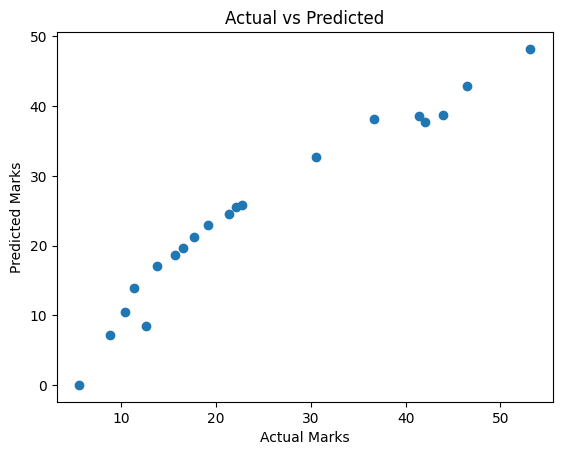

In [124]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

In [126]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [125]:
# Insight 1

# Study time has a strong positive impact on student performance.

# 💡 Insight 2

# Number of courses shows weaker influence, indicating that increasing workload does not directly improve scores.

# 💡 Insight 3

# The regression model achieves an R² score of X, meaning it can explain a significant portion of performance variation.

In [129]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
# StudyTime has a higher coefficient than NumberOfCourses, indicating it is the dominant factor affecting performance.

Coefficients: [12.67532881  3.31564279]
Intercept: 24.369675


In [ ]:
# This analysis shows that study time is the most significant factor influencing student performance, while increasing the number of courses does not necessarily improve results. The regression model demonstrates a strong predictive capability, indicating that student scores can be reasonably estimated based on study habits.